In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

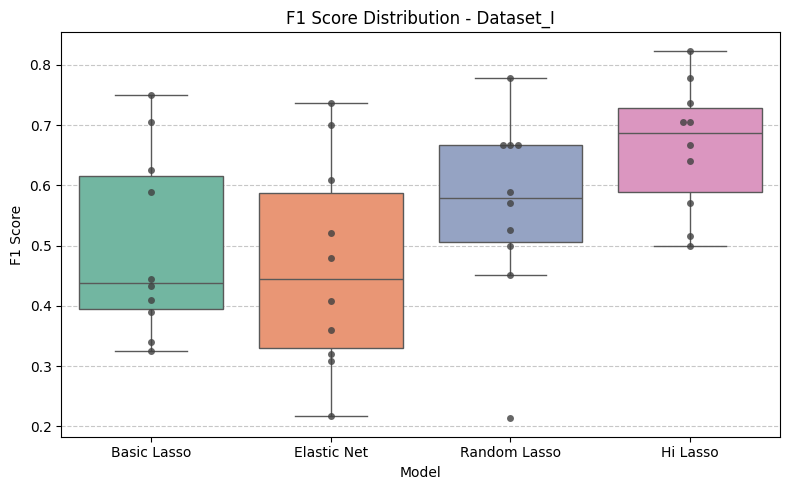

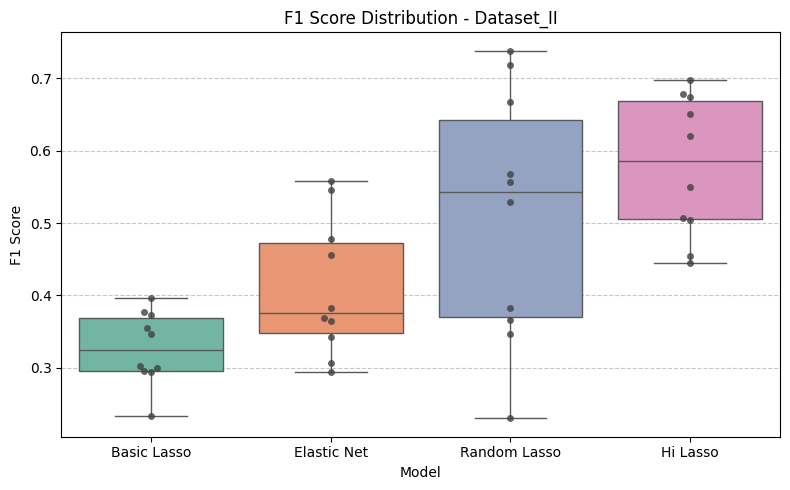

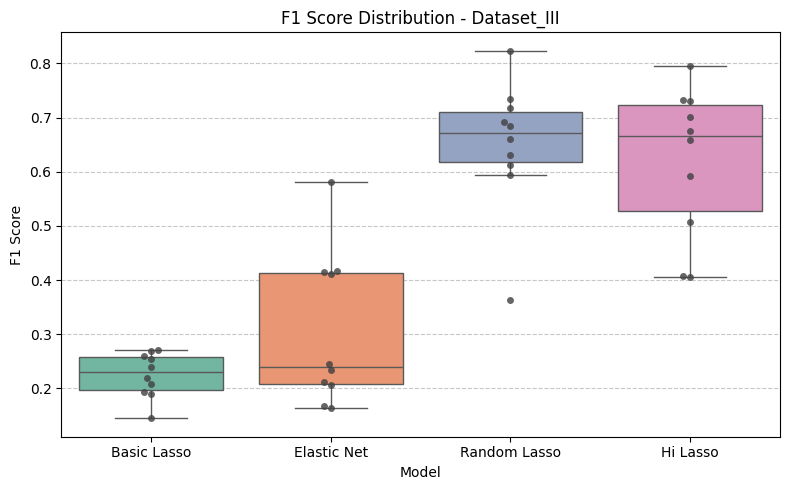

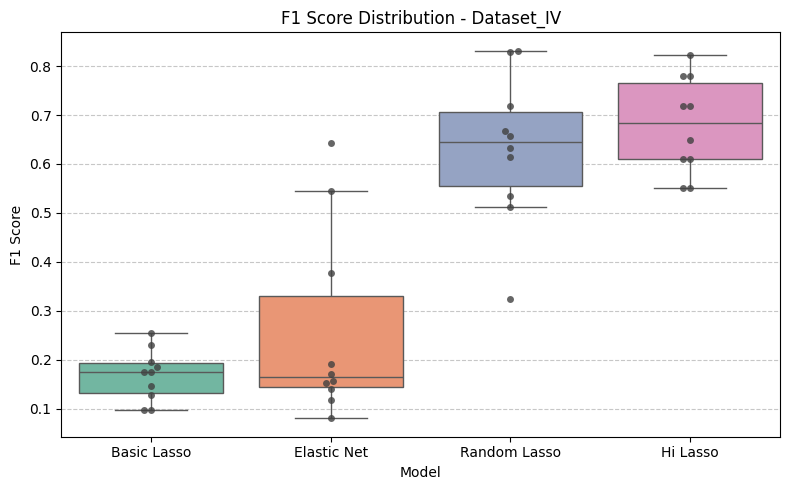

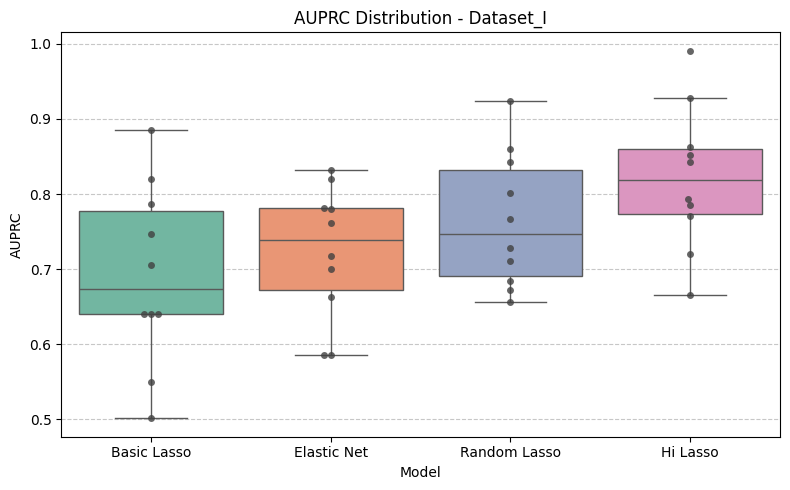

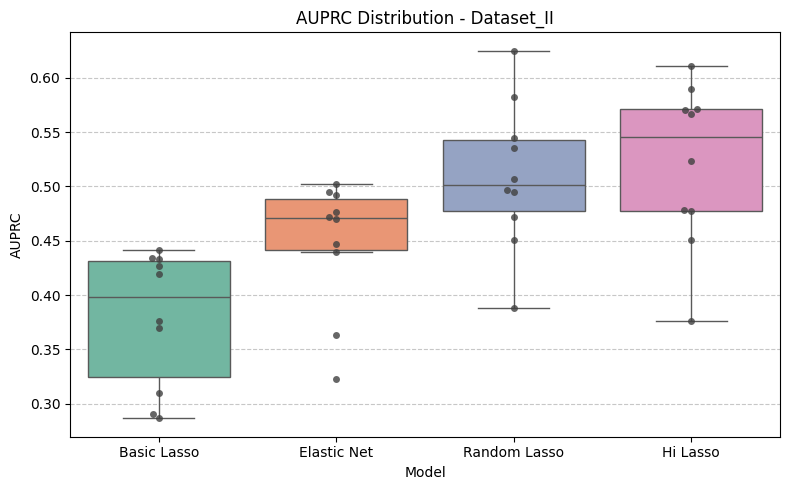

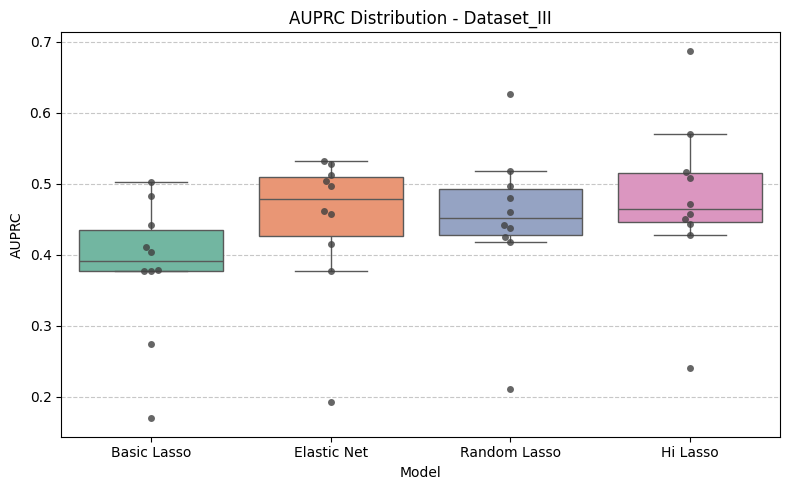

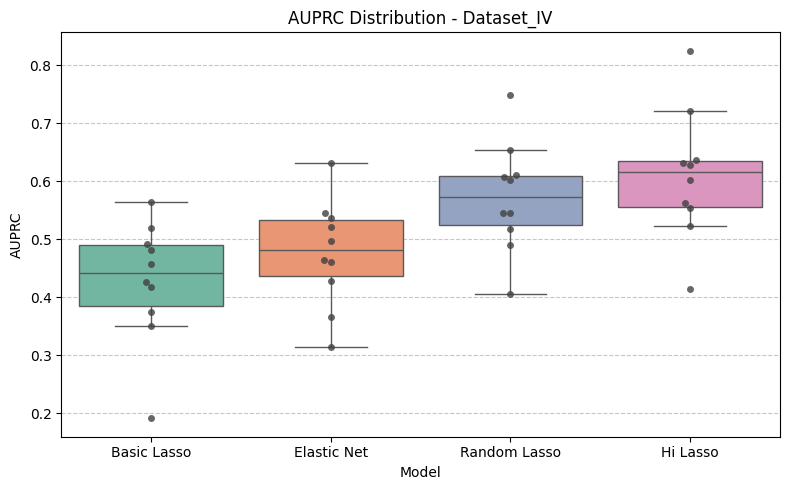

In [18]:
# 1. Load Data
df_base = pd.read_csv("master_base_metrics.csv")
df_rlasso = pd.read_csv("master_rlasso_metrics.csv")
df_hi = pd.read_csv("hilasso_scores.csv")

# Replace the df_lasso and df_elastic lines in Step 2 with this:
df_lasso = df_base[['Dataset', 'Seed', 'Alpha', 'L_RMSE', 'L_F1', 'L_AUPRC']].copy()
df_lasso = df_lasso.rename(columns={'L_RMSE': 'RMSE', 'L_F1': 'F1 Score', 'L_AUPRC': 'AUPRC'})
df_lasso['Model'] = 'Basic Lasso'

df_elastic = df_base[['Dataset', 'Seed', 'Alpha', 'E_RMSE', 'E_F1', 'E_AUPRC']].copy()
df_elastic = df_elastic.rename(columns={'E_RMSE': 'RMSE', 'E_F1': 'F1 Score', 'E_AUPRC': 'AUPRC'})
df_elastic['Model'] = 'Elastic Net'

df_base_long = pd.concat([df_lasso, df_elastic], ignore_index=True)

# 3. Filter base models: Pick best alpha (min RMSE) per Dataset, Seed, and Model
best_base_idx = df_base_long.groupby(["Dataset", "Seed", "Model"])["RMSE"].idxmin()
df_base_filtered = df_base_long.loc[best_base_idx]

# 4. Prepare Random Lasso and Hi Lasso data
# Dynamically find the column containing 'F1' for Random Lasso
rlasso_f1_cols = [col for col in df_rlasso.columns if 'F1' in col.upper()]
if rlasso_f1_cols:
    df_rlasso = df_rlasso.rename(columns={rlasso_f1_cols[0]: 'F1 Score'})
else:
    print("Columns in df_rlasso:", df_rlasso.columns.tolist())
    raise KeyError("Could not find an 'F1' column in Random Lasso data.")
df_rlasso['Model'] = 'Random Lasso'

# Extract AUPRC for Random Lasso
rlasso_auprc_cols = [col for col in df_rlasso.columns if 'AUPRC' in col.upper()]
if rlasso_auprc_cols:
    df_rlasso = df_rlasso.rename(columns={rlasso_auprc_cols[0]: 'AUPRC'})

# Dynamically find the column containing 'F1' for Hi Lasso
hi_f1_cols = [col for col in df_hi.columns if 'F1' in col.upper()]
if hi_f1_cols:
    df_hi = df_hi.rename(columns={hi_f1_cols[0]: 'F1 Score'})
else:
    print("Columns in df_hi:", df_hi.columns.tolist())
    raise KeyError("Could not find an 'F1' column in Hi Lasso data.")
df_hi['Model'] = 'Hi Lasso'

# Extract AUPRC for Hi Lasso
hi_auprc_cols = [col for col in df_hi.columns if 'AUPRC' in col.upper()]
if hi_auprc_cols:
    df_hi = df_hi.rename(columns={hi_auprc_cols[0]: 'AUPRC'})

# 5. Merge all models together for plotting
cols_to_keep = ['Dataset', 'Model', 'F1 Score', 'AUPRC']
df_full = pd.concat([
    df_base_filtered[cols_to_keep], 
    df_rlasso[cols_to_keep], 
    df_hi[cols_to_keep]
], ignore_index=True)

# 6. Plotting (4 Figures)
datasets = df_full["Dataset"].unique()
metrics_to_plot = ['F1 Score', 'AUPRC']

for metric in metrics_to_plot:
    for ds in datasets:
        plt.figure(figsize=(8, 5))
        ds_data = df_full[df_full["Dataset"] == ds]
        
        # 6a. Box and Whisker Plot
        sns.boxplot(
            x="Model", 
            y=metric, # Now dynamically plotting the metric
            data=ds_data, 
            palette="Set2",
            showfliers=False 
        )
        
        # 6b. Specific Points (Swarm Plot)
        sns.swarmplot(
            x="Model", 
            y=metric, # Now dynamically plotting the metric
            data=ds_data, 
            color=".25", 
            alpha=0.8,
            size=5
        )
        
        plt.title(f"{metric} Distribution - {ds}")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

Model offsets: {'Basic Lasso': np.float64(-0.36), 'Elastic Net': np.float64(-0.12), 'Random Lasso': np.float64(0.12), 'Hi-LASSO': np.float64(0.36)}


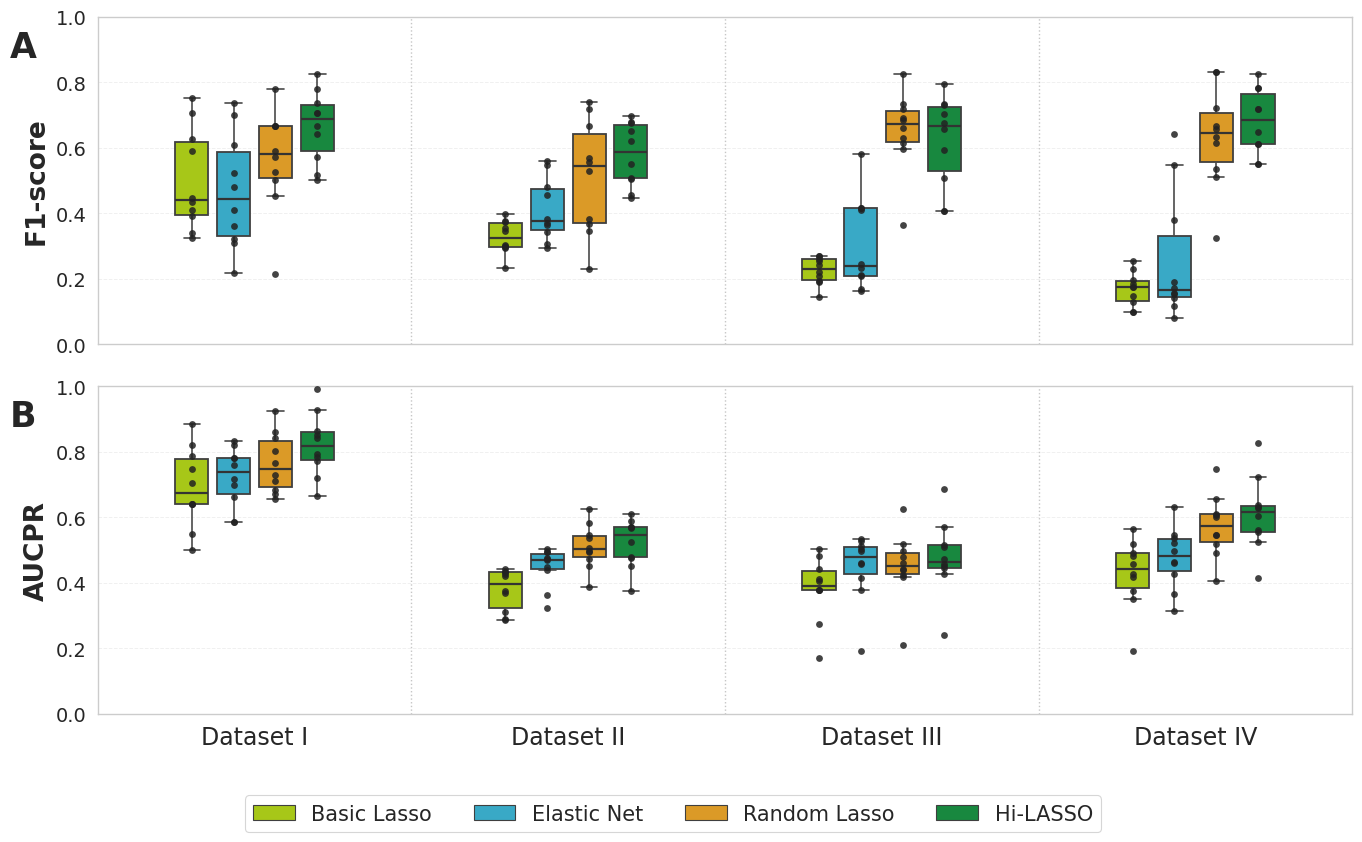

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Note: Visualization aesthetic layout contributed by Seongyun Ryu

# =====================================================
# Dataset / Model Configuration
# =====================================================
dataset_order = [
    "Dataset_I",
    "Dataset_II",
    "Dataset_III",
    "Dataset_IV"
]

dataset_labels = [
    "Dataset I",
    "Dataset II",
    "Dataset III",
    "Dataset IV"
]

model_order = [
    "Basic Lasso",
    "Elastic Net",
    "Random Lasso",
    "Hi-LASSO"
]

palette = {
    "Basic Lasso": "#A7C718",
    "Elastic Net": "#39A9C6",
    "Random Lasso": "#DB9A27",
    "Hi-LASSO": "#18883F"
}

# =====================================================
# Box Position Configuration
# =====================================================

# Spacing between Dataset centers
group_spacing = 1.8

# Exact center of each Dataset
group_centers = (
    np.arange(len(dataset_order)) * group_spacing
)

# Spacing between models within a Dataset
model_spacing = 0.24

# Symmetrical arrangement of the 4 models around 0
offset_values = (
    np.arange(len(model_order))
    - (len(model_order) - 1) / 2
) * model_spacing

model_offsets = dict(
    zip(model_order, offset_values)
)

print("Model offsets:", model_offsets)
# Symmetrical center in the form of [-0.36, -0.12, 0.12, 0.36]

box_width = 0.19

# =====================================================
# Figure Setup
# =====================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 8.5),
    sharex=True
)

plot_info = [
    ("F1 Score", "F1-score", "A"),
    ("AUCPR", "AUCPR", "B")
]

for ax, (metric, ylabel, panel_label) in zip(
    axes,
    plot_info
):

    for dataset_idx, dataset in enumerate(
        dataset_order
    ):

        dataset_center = group_centers[dataset_idx]

        for model in model_order:

            values = df_full.loc[
                (df_full["Dataset"] == dataset)
                & (df_full["Model"] == model),
                metric
            ].dropna().to_numpy()

            if len(values) == 0:
                continue

            # Exact same center to be used by boxes and points
            x_position = (
                dataset_center
                + model_offsets[model]
            )

            # ------------------------------
            # Boxplot
            # ------------------------------
            bp = ax.boxplot(
                values,
                positions=[x_position],
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                whis=1.5,
                medianprops={
                    "color": "#333333",
                    "linewidth": 1.6
                },
                boxprops={
                    "edgecolor": "#3F3F3F",
                    "linewidth": 1.3
                },
                whiskerprops={
                    "color": "#4A4A4A",
                    "linewidth": 1.2
                },
                capprops={
                    "color": "#4A4A4A",
                    "linewidth": 1.2
                }
            )

            bp["boxes"][0].set_facecolor(
                palette[model]
            )

            # ------------------------------
            # 10 points per experiment
            # ------------------------------
            point_x = np.full(
                len(values),
                x_position
            )

            ax.scatter(
                point_x,
                values,
                s=24,
                color="#222222",
                alpha=0.85,
                linewidth=0,
                zorder=4
            )

    # =================================================
    # Y-axis Configuration
    # =================================================
    ax.set_ylim(0, 1)
    ax.set_yticks(
        np.arange(0, 1.01, 0.2)
    )

    ax.set_ylabel(
        ylabel,
        fontsize=19,
        fontweight="bold"
    )

    ax.set_xlabel("")

    # Panel indicator A / B
    ax.text(
        -0.07,
        0.96,
        panel_label,
        transform=ax.transAxes,
        fontsize=25,
        fontweight="bold",
        va="top"
    )

    # =================================================
    # Dataset Separator Lines
    # =================================================
    for i in range(
        len(group_centers) - 1
    ):
        separator_position = (
            group_centers[i]
            + group_centers[i + 1]
        ) / 2

        ax.axvline(
            separator_position,
            color="#A0A0A0",
            linestyle=":",
            linewidth=1.0,
            alpha=0.6,
            zorder=0
        )

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.7,
        alpha=0.3
    )

    ax.grid(
        axis="x",
        visible=False
    )

    ax.tick_params(
        axis="y",
        labelsize=14
    )

# =====================================================
# X-axis Center and Range
# =====================================================

# Position Dataset names at the exact center of each box group
axes[-1].set_xticks(group_centers)
axes[-1].set_xticklabels(
    dataset_labels,
    fontsize=17
)

axes[0].tick_params(
    axis="x",
    bottom=False,
    labelbottom=False
)

# Most important modification:
# Ensure the width of each Dataset section is exactly the same
half_group_spacing = group_spacing / 2

for ax in axes:
    ax.set_xlim(
        group_centers[0] - half_group_spacing,
        group_centers[-1] + half_group_spacing
    )

# =====================================================
# Legend
# =====================================================
legend_handles = [
    Patch(
        facecolor=palette[model],
        edgecolor="#3F3F3F",
        label=model
    )
    for model in model_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    fontsize=15,
    frameon=True,
    bbox_to_anchor=(0.5, -0.005)
)

plt.tight_layout(
    rect=[0.02, 0.08, 1, 1],
    h_pad=1.2
)

plt.savefig(
    "figures/combined_F1_AUCPR_centered.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "figures/combined_F1_AUCPR_centered.pdf",
    bbox_inches="tight"
)

plt.show()